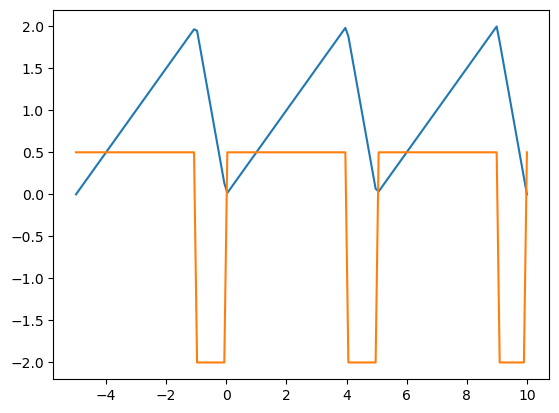

In [16]:
import numpy as np
import matplotlib.pyplot as plt

t0 = 5
t1 = 4
a = 2

def U(t,t1,t0,a):
    phase = t % t0
    if 0 <= phase <= t1:
        return a*phase/t1
    elif phase > t1:
        return a-a*(phase-t1)/(t0-t1)

t = np.linspace(-5,10,150)
ut = np.empty_like(t)
for i in range(len(ut)):
    ut[i] = U(t[i],t1,t0,a)

plt.plot(t, ut)

def F(t):
    phase = t % t0
    if 0 <= phase <= t1:
        return a/t1
    elif phase > t1:
        return -a/(t0-t1)

ft = np.empty_like(t)
for i in range(len(ft)):
    ft[i] = F(t[i])

plt.plot(t,ft)

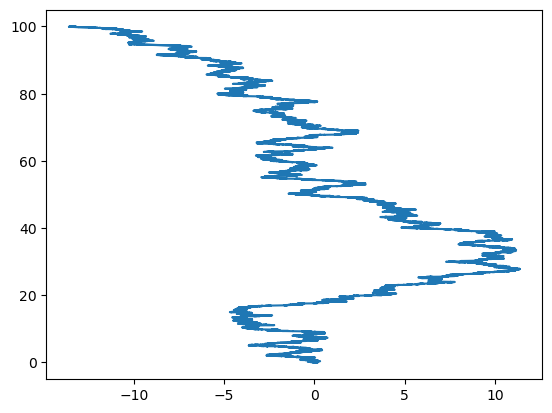

In [23]:
from LSolver import SimulationConfig_new, underdamped

beta = 1.0
T = 1/beta
gma = 2.0

cfg = SimulationConfig_new(
    gamma = gma,
    F_func = lambda t,x,y: F(t),
    Tx_func = lambda t,x,y: T,
    Ty_func = lambda t,x,y: 0.5*T,
    t_max = 100.0,
    dt = 0.001
)

rng = np.random.default_rng(seed = 42)

data = underdamped(cfg, rng = rng)[0]

plt.plot(data, cfg.t_array)